# Predicción de Abandono Estudiantil
## Análisis y Modelo de Clasificación

**Objetivo:** Predecir si un estudiante abandonará sus estudios universitarios 
basándose en variables académicas, socioeconómicas y demográficas.

**Dataset:** Higher Education Predictors of Student Retention (UCI)  
**Autor:** Niurka Vanesa Yupanqui  
**Herramientas:** Python, pandas, scikit-learn, XGBoost


In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [2]:
# Cargar datos
df = pd.read_csv('../data/dataset.csv')

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 4424
Columnas: 35


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print ("Tipos de datos:")
print (df.dtypes)
print ("Valores nulos por columna:")
print (df.isnull().sum())
print ("Target")
print (df['Target'].value_counts())

Tipos de datos:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int6

In [4]:
#Limpiamos el Target ----> Eliminar Enrolled 
df = df[df['Target'] != 'Enrolled']
print(f"Estudiantes restante:{len(df)}")
print(f"Droput:{len(df[df['Target'] == 'Dropout'])}")
print(f"Graduate:{len(df[df['Target'] == 'Graduate'])}")

# Convertir target a numeros, donde Dropout = 1 y Graduate = 0
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})

print ("Tipos de datos convertidos:")
print (df['Target'].value_counts())


Estudiantes restante:3630
Droput:1421
Graduate:2209
Tipos de datos convertidos:
Target
0    2209
1    1421
Name: count, dtype: int64


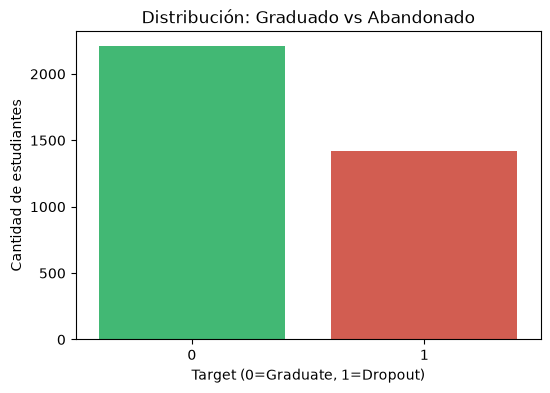

In [5]:
#Visualización de la distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target' , palette = ["#2ecc71", "#e74c3c"])
plt.title('Distribución: Graduado vs Abandonado')
plt.xlabel('Target (0=Graduate, 1=Dropout)')
plt.ylabel('Cantidad de estudiantes')
plt.show()

In [6]:
# Variables más correlacionadas con el abandono
correlaciones = df.corr(numeric_only=True)['Target'].sort_values(ascending=False)
print(correlaciones)



Target                                            1.000000
Age at enrollment                                 0.267229
Debtor                                            0.267207
Gender                                            0.251955
Application mode                                  0.233888
Previous qualification                            0.102795
Curricular units 2nd sem (without evaluations)    0.102687
Marital status                                    0.100479
Curricular units 1st sem (without evaluations)    0.074642
Mother's qualification                            0.048459
Inflation rate                                    0.030326
Educational special needs                         0.007254
Father's qualification                            0.003850
Nacionality                                       0.003823
Unemployment rate                                -0.004198
International                                    -0.006181
Course                                           -0.0068

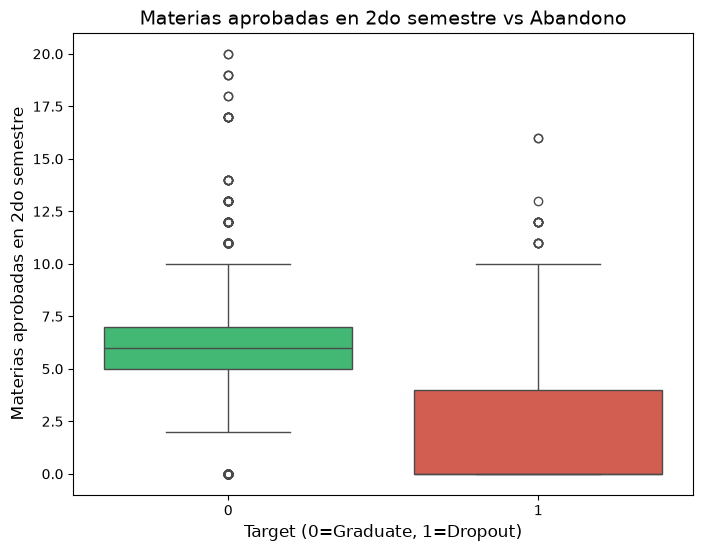

In [7]:
# Boxplot: Materias aprobadas en 2do semestre vs Target (Materias aprobadas en 2do semestre es la variable más correlacionada )
# Primera Variable Correlacionada: Curricular units 2nd sem (approved)
plt.figure(figsize=(8,6))
sns.boxplot(x ='Target', y = 'Curricular units 2nd sem (approved)', data = df, palette = ["#2ecc71", "#e74c3c"])

plt.title('Materias aprobadas en 2do semestre vs Abandono', fontsize=14)
plt.xlabel('Target (0=Graduate, 1=Dropout)', fontsize=12)
plt.ylabel('Materias aprobadas en 2do semestre', fontsize=12)
plt.show()


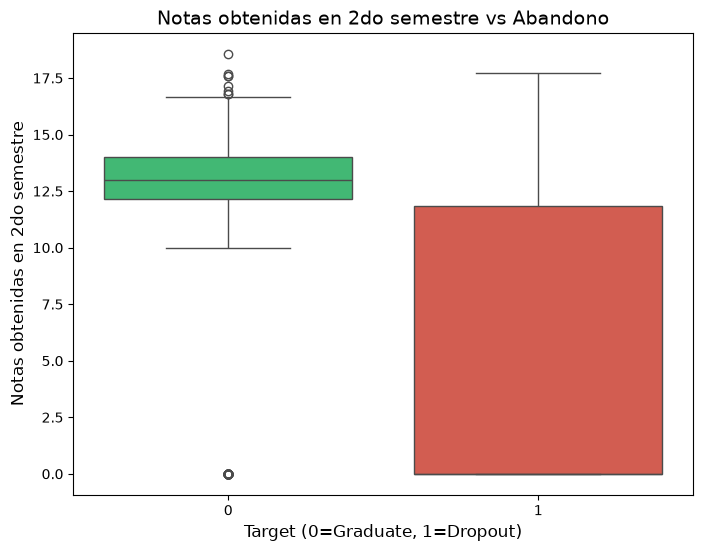

In [8]:
# Boxplot: Notas obtenidas en 2do semestre vs Target (Notas obtenidas en 2do semestre es la segunda variable más correlacionada )
# Segunda Variable Correlacionada: Curricular units 2nd sem (grade)
plt.figure(figsize=(8,6))
sns.boxplot(x ='Target', y = 'Curricular units 2nd sem (grade)', data = df, palette = ["#2ecc71", "#e74c3c"])

plt.title('Notas obtenidas en 2do semestre vs Abandono', fontsize=14)
plt.xlabel('Target (0=Graduate, 1=Dropout)', fontsize=12)
plt.ylabel('Notas obtenidas en 2do semestre', fontsize=12)
plt.show()


In [9]:
df['Debtor'].value_counts()

Debtor
0    3217
1     413
Name: count, dtype: int64

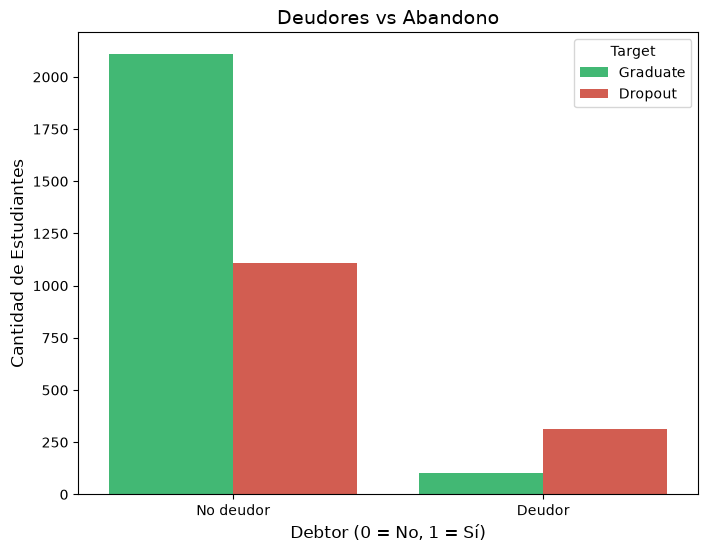

In [10]:
# Countplot: Debtor vs Target
# Variable categórica con correlación positiva (0.27)

plt.figure(figsize=(8, 6))
sns.countplot(x='Debtor', hue='Target', data=df, palette=['#2ecc71', '#e74c3c'])

plt.title('Deudores vs Abandono', fontsize=14)
plt.xlabel('Debtor (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Estudiantes', fontsize=12)
plt.xticks([0, 1], ['No deudor', 'Deudor'])
plt.legend(title='Target', labels=['Graduate', 'Dropout'])

plt.show()

In [11]:
# Esto te va a dar las proporciones exactas de Debtor vs Target
#Si NO debes → tienes 34% de probabilidad de abandonar
#Si SÍ debes → tienes 75% de probabilidad de abandonar 
df.groupby('Debtor')['Target'].mean()

Debtor
0    0.344731
1    0.755448
Name: Target, dtype: float64

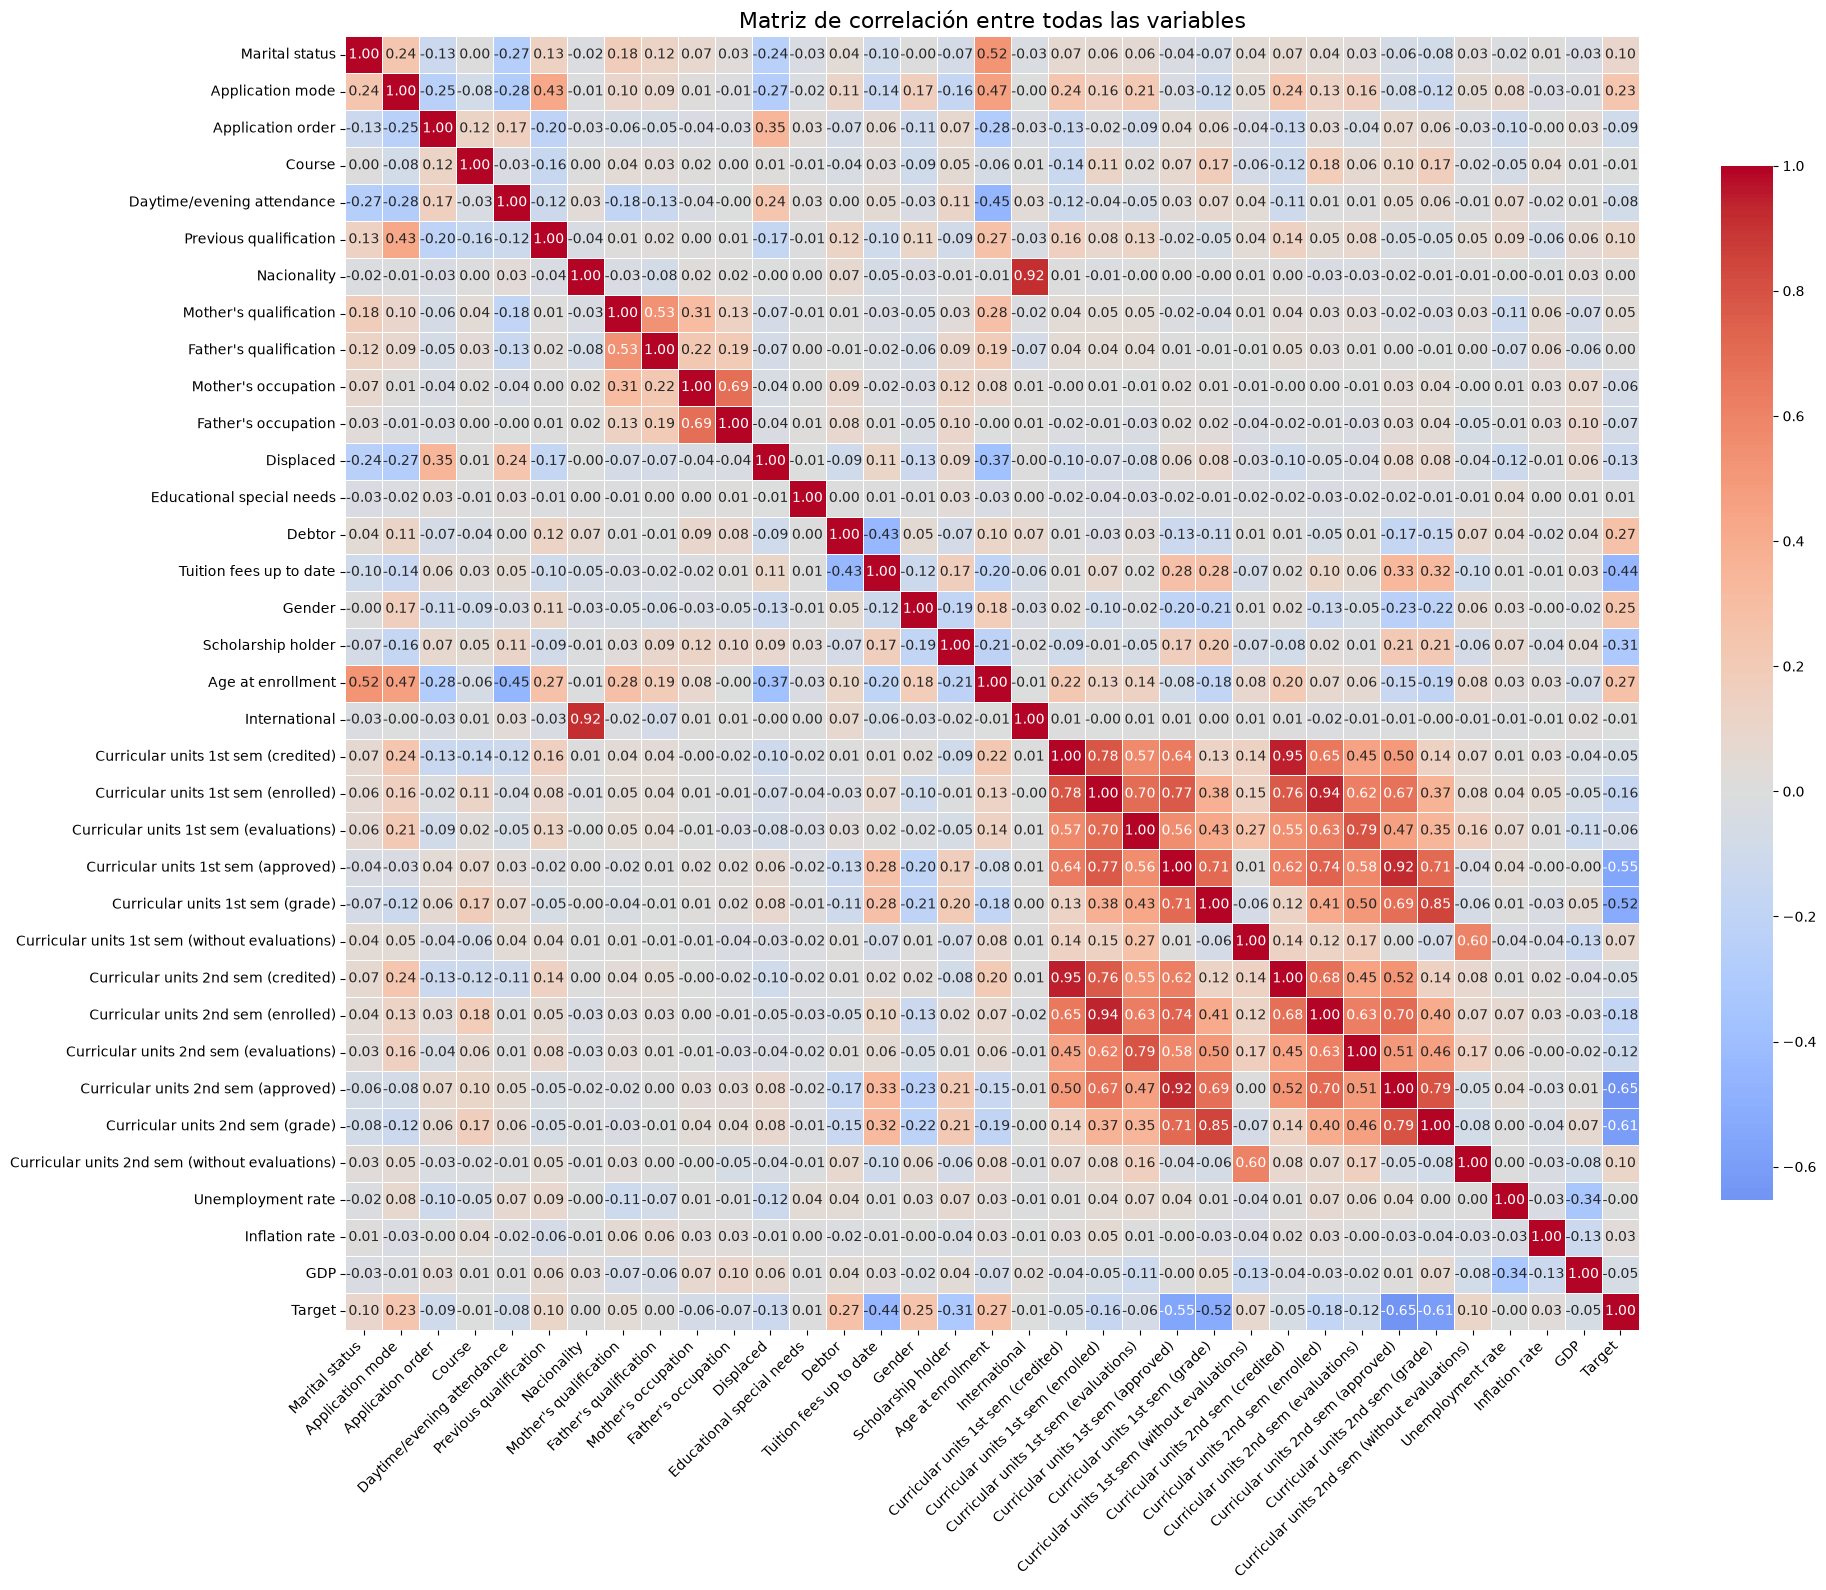

In [12]:
# Celda 10: Heatmap de correlaciones

# Paso 1: Calculamos la matriz de correlación de TODAS las variables numéricas
# .corr() compara cada columna contra todas las demás y devuelve una tabla
# (matriz) con el coeficiente de correlación de cada par
matriz_correlacion = df.corr(numeric_only=True)

# Paso 2: Creamos la figura donde vamos a dibujar
# figsize=(20, 16) es el tamaño en pulgadas (ancho, alto)
# Con 35 columnas necesitamos algo grande, si no, no se va a leer nada
plt.figure(figsize=(20, 16))

# Paso 3: Dibujamos el heatmap con seaborn
sns.heatmap(
    matriz_correlacion,      # la tabla de correlaciones que calculamos arriba
    annot=True,               # True = escribe el número dentro de cada celda
    fmt='.2f',                # formato del número: 2 decimales (ej: 0.65)
    cmap='coolwarm',          # paleta de colores: azul (negativo) a rojo (positivo)
    center=0,                 # el color blanco/neutro corresponde al valor 0
    square=True,               # cada celda es un cuadrado perfecto (más prolijo)
    linewidths=0.5,           # líneas delgadas entre celdas para separarlas
    cbar_kws={'shrink': 0.8}  # la barra de colores de la derecha, un poco más chica
)

# Paso 4: Título y ajustes finales
plt.title('Matriz de correlación entre todas las variables', fontsize=16)
plt.xticks(rotation=45, ha='right')  # nombres del eje X inclinados, para que no se pisen
plt.tight_layout()                    # ajusta todo para que no se corte nada
plt.show()